# Individual Energy-Profile Prediction — curve-approach evaluation

The per-activity **individual curve** prediction benchmark (Baseline, ML DTW,
ML + Ext. Factors, Seq2Seq, …) — the same evaluation as in `results_latex_table`,
extracted on its own.

- Source: `curve_eval_results.parquet` (per-curve records with an **Activity**
  dimension, unlike the `summary_train_test` file the old notebook used).
- Granularity: aggregated **process × activity × sensor**, then across those with
  the **median** (metrics: sMAE, sRMSE, WAPE).
- One table **per process** (all methods) + one **aggregated** table (all
  processes), both as styled tables and LaTeX.
- **Boxplots** of the aggregated per-(process, activity, sensor) values, in the
  same style as the sMAE boxplot in `results_latex_table`.

In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

EXPERIMENT = 963
SPLIT      = 'TEST'                       # 'TEST' or 'TRAIN'
METRICS    = ['sMAE', 'sRMSE', 'WAPE']    # WAPE is a percentage
BOX_METRIC = 'sMAE'                       # metric for the boxplots
EXCLUDE_APPROACHES = []                   # e.g. ['ML DTW + Linear Decode'] to drop variants
SAVE_LATEX = True

results_root = Path('..') / 'results'
runs = sorted([d for d in results_root.iterdir()
               if d.is_dir() and d.name.startswith(f'experiment_{EXPERIMENT}_')])
assert runs, f'No runs for experiment {EXPERIMENT}'
run_dir = runs[-1]
print('Using run:', run_dir.name)

Using run: experiment_963_20260722_180634


In [2]:
# ── Load + aggregate to (process, activity, sensor, approach) ────────────────
raw = pd.read_parquet(run_dir / 'curve_eval_results.parquet')
raw = raw[raw['Split'] == SPLIT]
if EXCLUDE_APPROACHES:
    raw = raw[~raw['Approach'].isin(EXCLUDE_APPROACHES)]
print(f'{len(raw):,} per-curve rows | approaches: {raw["Approach"].nunique()} | '
      f'processes: {sorted(raw["Process"].unique())}')

# Stage 1: one value per (process, activity, sensor, approach) = median over its curves
combo = (raw.groupby(['Process', 'Activity', 'Sensor', 'Approach'])[METRICS]
            .median().reset_index())
print('per (process, activity, sensor, approach) rows:', len(combo))

215,497 per-curve rows | approaches: 8 | processes: ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']
per (process, activity, sensor, approach) rows: 4191


In [3]:
# ── Table helpers (bold best per column; lower = better) ─────────────────────
def approach_table(df_combo):
    # median across (activity, sensor[, process]) per approach
    t = df_combo.groupby('Approach')[METRICS].median()
    return t.sort_values(BOX_METRIC)          # best (lowest) first

def style_table(t):
    return (t.style.format({m: '{:.3f}' for m in t.columns}, na_rep='—')
             .highlight_min(axis=0, props='font-weight:700;background-color:#d6ecff;')
             .set_caption(f'{SPLIT} — median over process×activity×sensor; lower = better'))

def to_latex(t, caption, label):
    s = pd.DataFrame(index=t.index, columns=t.columns, dtype=object)
    for col in t.columns:
        vals = t[col].dropna(); best = vals.min() if not vals.empty else None
        for idx in t.index:
            v = t.loc[idx, col]
            s.loc[idx, col] = ('' if pd.isna(v) else
                               (r'\textbf{' + f'{v:.3f}' + '}') if (best is not None and abs(v-best) < 1e-6)
                               else f'{v:.3f}')
    latex = s.to_latex(escape=False, column_format='l|' + '|'.join(['c']*len(t.columns)),
                       caption=caption, label=label, position='H')
    return latex.replace('_', r'\_')

## 1 · Aggregated — all processes

In [4]:
agg = approach_table(combo)
display(style_table(agg))

,sMAE,sRMSE,WAPE
Approach,,,
ML + Ext. Factors + Prev Act,1.287,1.506,6.120
ML DTW,1.819,2.044,11.456
Median per Activity & Sensor,1.838,2.098,8.573
DTW + Seq2Seq + Ext. Factors + Prev Act,1.875,2.098,9.871
DTW + Seq2Seq,1.918,2.218,11.867
ML only (no DTW),2.228,2.466,12.973
Baseline,2.300,2.525,11.766
Seq2Seq only (no DTW),2.328,2.583,12.895


## 2 · Per process (all methods)

In [5]:
per_process = {}
for proc in sorted(combo['Process'].unique()):
    t = approach_table(combo[combo['Process'] == proc])
    per_process[proc] = t
    display(Markdown(f'### {proc}'))
    display(style_table(t))

### process_1

,sMAE,sRMSE,WAPE
Approach,,,
ML only (no DTW),0.327,1.021,16.465
ML DTW,0.329,1.038,16.639
Median per Activity & Sensor,0.341,1.041,14.893
ML + Ext. Factors + Prev Act,0.381,1.024,14.480
DTW + Seq2Seq,0.393,1.034,15.603
Seq2Seq only (no DTW),0.476,1.034,19.262
DTW + Seq2Seq + Ext. Factors + Prev Act,0.485,1.007,13.263
Baseline,2.045,2.283,100.000


### process_2

,sMAE,sRMSE,WAPE
Approach,,,
ML DTW,0.428,0.794,32.848
ML + Ext. Factors + Prev Act,0.452,0.824,27.873
Median per Activity & Sensor,0.585,1.009,36.027
DTW + Seq2Seq + Ext. Factors + Prev Act,0.684,0.974,50.185
DTW + Seq2Seq,0.690,1.002,53.849
ML only (no DTW),0.773,1.040,42.304
Seq2Seq only (no DTW),0.887,1.034,54.033
Baseline,1.565,1.682,84.372


### process_3

...

,sMAE,sRMSE,WAPE
Approach,,,
ML + Ext. Factors + Prev Act,2.014,2.211,5.745
Median per Activity & Sensor,2.390,2.599,6.516
Baseline,2.543,2.715,6.502
ML DTW,2.557,2.723,8.773
DTW + Seq2Seq,2.564,2.761,9.017
DTW + Seq2Seq + Ext. Factors + Prev Act,2.581,2.771,8.832
Seq2Seq only (no DTW),2.622,2.803,8.886
ML only (no DTW),2.798,2.975,8.981


### process_4_2

,sMAE,sRMSE,WAPE
Approach,,,
DTW + Seq2Seq + Ext. Factors + Prev Act,3.735,3.898,9.785
ML + Ext. Factors + Prev Act,3.761,3.864,7.975
Median per Activity & Sensor,3.814,3.950,14.072
Seq2Seq only (no DTW),4.609,4.752,15.557
ML DTW,4.669,4.734,14.253
DTW + Seq2Seq,4.682,4.802,14.145
Baseline,4.918,5.031,16.303
ML only (no DTW),5.204,5.306,15.463


### process_5

,sMAE,sRMSE,WAPE
Approach,,,
ML + Ext. Factors + Prev Act,1.163,1.409,3.685
ML DTW,1.819,2.044,6.087
Baseline,2.035,2.242,6.328
DTW + Seq2Seq,2.078,2.286,7.053
Median per Activity & Sensor,2.118,2.299,5.784
DTW + Seq2Seq + Ext. Factors + Prev Act,2.134,2.316,6.023
ML only (no DTW),2.342,2.552,7.096
Seq2Seq only (no DTW),2.504,2.750,8.794


## 3 · LaTeX

In [6]:
out = run_dir / 'process_metrics_tables'
if SAVE_LATEX: out.mkdir(exist_ok=True)

tex_agg = to_latex(agg,
    caption=(f'Individual energy-profile prediction ({SPLIT} set), all processes. Median over '
             r'(process, activity, sensor) of each curve metric; lower is better. '
             r'\textbf{Bold} = best approach per metric.'),
    label=f'tab:individual_profile_all_{EXPERIMENT}')
if SAVE_LATEX: (out / 'individual_profile_all.tex').write_text(tex_agg)
print('% ===== ALL PROCESSES ====='); print(tex_agg)

for proc, t in per_process.items():
    tex = to_latex(t,
        caption=(f'Individual energy-profile prediction for {proc} ({SPLIT} set). Median over '
                 r'(activity, sensor) of each curve metric; lower is better. '
                 r'\textbf{Bold} = best approach per metric.'),
        label=f'tab:individual_profile_{proc}_{EXPERIMENT}')
    if SAVE_LATEX: (out / f'individual_profile_{proc}.tex').write_text(tex)
    print(f'\n% ===== {proc} ====='); print(tex)
if SAVE_LATEX: print('\nSaved .tex to', out)

% ===== ALL PROCESSES =====
\begin{table}[H]
\caption{Individual energy-profile prediction (TEST set), all processes. Median over (process, activity, sensor) of each curve metric; lower is better. \textbf{Bold} = best approach per metric.}
\label{tab:individual\_profile\_all\_963}
\begin{tabular}{l|c|c|c}
\toprule
 & sMAE & sRMSE & WAPE \\
Approach &  &  &  \\
\midrule
ML + Ext. Factors + Prev Act & \textbf{1.287} & \textbf{1.506} & \textbf{6.120} \\
ML DTW & 1.819 & 2.044 & 11.456 \\
Median per Activity & Sensor & 1.838 & 2.098 & 8.573 \\
DTW + Seq2Seq + Ext. Factors + Prev Act & 1.875 & 2.098 & 9.871 \\
DTW + Seq2Seq & 1.918 & 2.218 & 11.867 \\
ML only (no DTW) & 2.228 & 2.466 & 12.973 \\
Baseline & 2.300 & 2.525 & 11.766 \\
Seq2Seq only (no DTW) & 2.328 & 2.583 & 12.895 \\
\bottomrule
\end{tabular}
\end{table}


% ===== process_1 =====
\begin{table}[H]
\caption{Individual energy-profile prediction for process\_1 (TEST set). Median over (activity, sensor) of each curve metric; lower 

## 4 · Boxplot — aggregated per (process, activity, sensor)

Same style as the sMAE boxplot in `results_latex_table`: one box per approach over
all (process, activity, sensor) values, sorted best-at-top, x-axis capped near the
95th percentile.

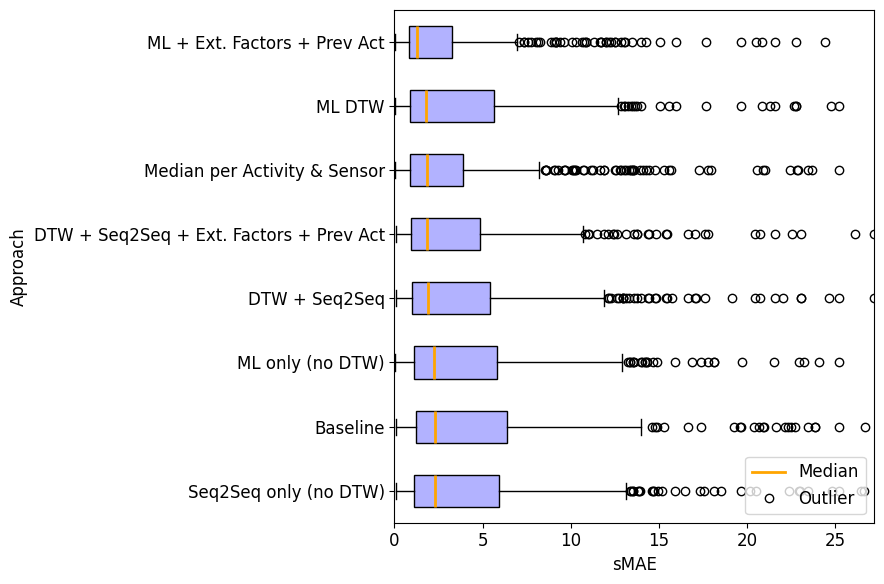

Saved: visuals/individual_profile_sMAE_boxplot.pdf


In [7]:
plt.rcParams.update({'font.size': 12})
df_box = combo[~combo['Approach'].isin(EXCLUDE_APPROACHES)]
box_order = df_box.groupby('Approach')[BOX_METRIC].median().sort_values(ascending=False).index.tolist()
data = [df_box.loc[df_box['Approach'] == a, BOX_METRIC].dropna().values for a in box_order]

fig, ax = plt.subplots(figsize=(9, 6))
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False,
                   patch_artist=True, medianprops=dict(color='orange', linewidth=2))
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)
for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
all_vals = np.concatenate([d for d in data if len(d)])
ax.set_xlim(0, np.percentile(all_vals, 95) * 1.3)
ax.set_xlabel(BOX_METRIC); ax.set_ylabel('Approach')
ax.legend(handles=[Line2D([0],[0],color='orange',lw=2,label='Median'),
                   Line2D([0],[0],marker='o',color='w',markeredgecolor='black',
                          markerfacecolor='none',markersize=6,label='Outlier')], loc='lower right')
fig.tight_layout()
Path('visuals').mkdir(exist_ok=True)
fig.savefig(f'visuals/individual_profile_{BOX_METRIC}_boxplot.pdf', dpi=300, bbox_inches='tight')
(run_dir/'plots').mkdir(exist_ok=True)
fig.savefig(run_dir/'plots'/f'individual_profile_{BOX_METRIC}_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: visuals/individual_profile_{BOX_METRIC}_boxplot.pdf')

### Boxplots for every metric

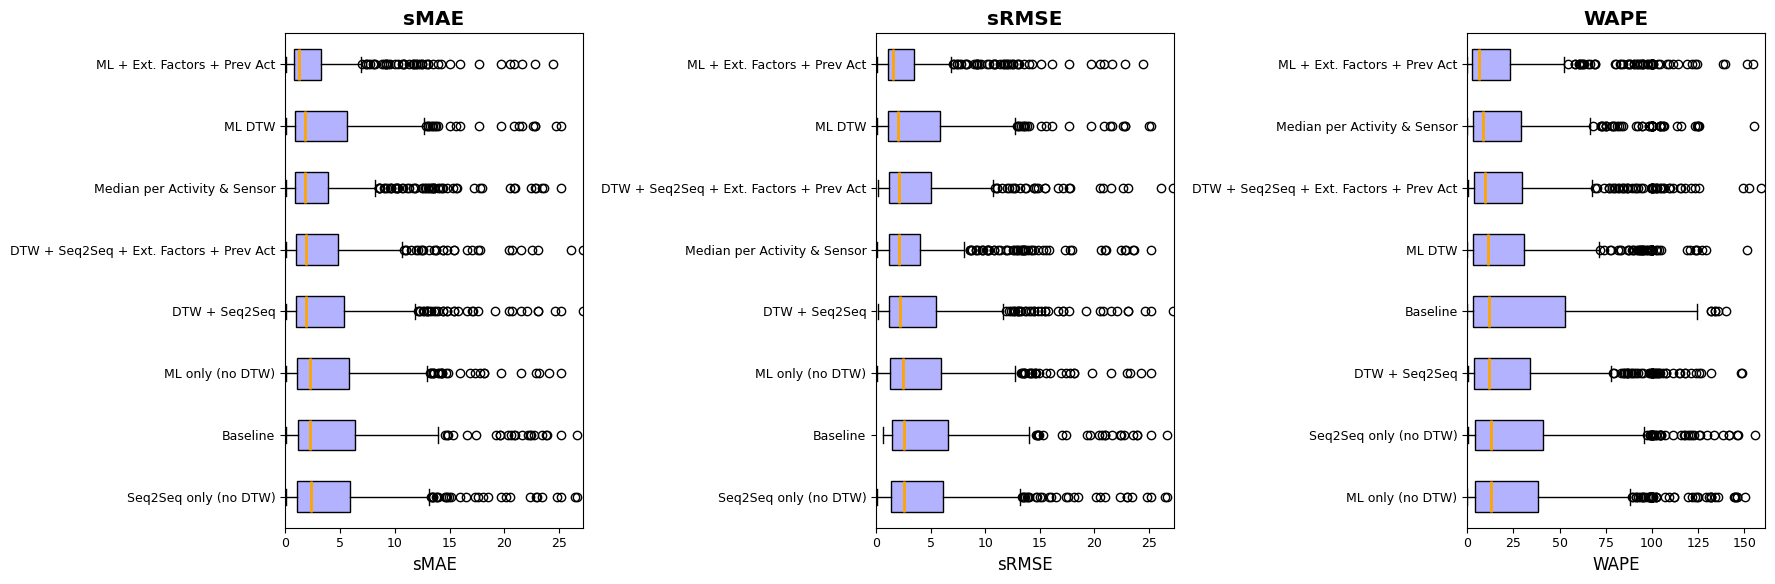

In [8]:
metrics = METRICS
fig, axes = plt.subplots(1, len(metrics), figsize=(6*len(metrics), 6))
axes = np.atleast_1d(axes)
for ax, metric in zip(axes, metrics):
    order = df_box.groupby('Approach')[metric].median().sort_values(ascending=False).index.tolist()
    data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in order]
    bp = ax.boxplot(data, tick_labels=order, showfliers=True, vert=False,
                    patch_artist=True, medianprops=dict(color='orange', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
    av = np.concatenate([d for d in data if len(d)])
    if len(av): ax.set_xlim(0, np.percentile(av, 95) * 1.3)
    ax.set_xlabel(metric); ax.set_title(metric, fontweight='bold')
    ax.tick_params(labelsize=9)
fig.tight_layout()
fig.savefig(run_dir/'plots'/'individual_profile_all_metrics_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()